In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

### Load data

In [2]:
# Load log-likelihood dataframe for naturalistic corpus
df_ll = pd.read_parquet('cacl_t1_onesentperline_lemmatized_lower_1grams_freqs_inner_ll.parquet')

# Same info for LLM-improved corpus
df_gpt = pd.read_parquet('sample_gpt35_improved_input_lemmatized_lower_1grams_freqs_inner_ll.parquet')

In [3]:
# Filter down to content words as defined in the paper
pos_tags = ['NOUN', 'ADJ', 'VERB', 'ADV']
min_chars = 3
df_cw = df_ll[(df_ll['pos'].isin(pos_tags)) &
              (df_ll['lemma'].str.isalpha()) &
              (df_ll['lemma'].str.len() >= min_chars)].copy()

In [4]:
# Compute significance based on critical value
df_cw['ll_signif'] = df_cw['ll'].apply(lambda x: 1 if x>15.13 else np.nan)

# Add a signed version (for correlations and visualization)
df_cw['signed_ll'] = df_cw.apply(lambda x: -(x.ll) if x.ratio_t2 < 1 else x.ll, axis=1)

In [5]:
# Load nearest neighbors
df_nns = pd.read_parquet('cacl_t1_onesentperline_lemmatized_lower__d100_w5_f10_sg_sim_avg_density_k100_compare.parquet')
df_nns['delta_nn'] = df_nns['mean2'] - df_nns['mean1']

# Merge main dataframe with nearest neighbors
df_cw = df_cw.merge(df_nns, left_on='target', right_index=True, how='left')

### Log-likelihood analysis

In [6]:
# Calculate how many words with significant log-likelihood
n_total = df_cw.shape[0]
n_signif = df_cw[df_cw['ll']>15.13].shape[0]
perc_signif = round(n_signif/n_total*100, 2)
print('All words:', n_total)
print('Signif LL:', n_signif, perc_signif)

All words: 71993
Signif LL: 9353 12.99


In [7]:
# How many with significant log-likelihood AND increase in frequency
n_signif_t2 = df_cw[(df_cw['ll_signif']==1) & (df_cw['ratio_t2']>1)].shape[0]
perc_signif_t2 = round(n_signif_t2 / n_signif * 100, 2)
print('Signif in t2:', n_signif_t2, perc_signif_t2)

Signif in t2: 5141 54.97


In [8]:
# Calculate correlation between log-likelihood and change in density
# (only for significant log-likelihood values)
corr_ll_nn_df = df_cw[df_cw['ll_signif']==1].dropna(subset=['delta_nn'])
rho, pval = spearmanr(corr_ll_nn_df['signed_ll'], corr_ll_nn_df['delta_nn'])
print(f'rho:    {round(rho, 3)}')
print(f'p-value: {pval:.3e}')

rho:    -0.263
p-value: 1.204e-115


### Strongest changes in frequency -- plot

In [9]:
# Collect words to plot from naturalistic corpus
topn = 10 # per direction
pos_tags = ['NOUN', 'ADJ', 'VERB', 'ADV']
min_chars = 3

# Filter per POS and direction (frequency rise/fall)
subdfs = []
for pos in pos_tags:
    subdf = df_ll.loc[(df_ll['pos'] == pos) &
                      (df_ll['lemma'].str.isalpha()) &
                      (df_ll['lemma'].str.len() >= min_chars)]\
                  .sort_values(by='ll', ascending=False)
    subdfs.append(subdf[subdf['ratio_t2']>1][:topn])
    subdfs.append(subdf[subdf['ratio_t2']<1][:topn])
topdf = pd.concat(subdfs, ignore_index=True)

# Make signed LL + merge with neighborhood density
topdf['signed_ll'] = topdf.apply(lambda x: -(x.ll) if x.ratio_t2 < 1 else x.ll, axis=1)
topdf = topdf.merge(df_nns, left_on='target', right_index=True)

In [10]:
# Collect words to plot from LLM-paraphrased corpus
topn = 100 # per direction
pos_tags = ['NOUN', 'ADJ', 'VERB', 'ADV']
min_chars = 3

# Filter per POS and direction (frequency rise/fall)
subdfs = []
for pos in pos_tags:
    subdf = df_gpt.loc[(df_gpt['pos'] == pos) &
                       (df_gpt['lemma'].str.isalpha()) &
                       (df_gpt['lemma'].str.len() >= min_chars)]\
                  .sort_values(by='ll', ascending=False)
    subdfs.append(subdf[subdf['ratio_t2']>1][:topn])
    subdfs.append(subdf[subdf['ratio_t2']<1][:topn])
topdf_gpt = pd.concat(subdfs, ignore_index=True)

# Make signed LL
topdf_gpt['signed_ll'] = topdf_gpt.apply(lambda x: -(x.ll) if x.ratio_t2 < 1 else x.ll, axis=1)

# No neighborhood density in this case -- corpus is to small for w2v

In [11]:
# Merge naturalistic + LLM corpus information
topdf = topdf.merge(topdf_gpt[['target', 'signed_ll']],
                    on='target', how='left',
                    suffixes=('', '_gpt'))

# Check if same frequency change in original and GPT
topdf['Corpus'] = topdf.apply(lambda x: x.signed_ll*x.signed_ll_gpt>0, axis=1)
topdf['Corpus'] = topdf['Corpus'].map({True: 'original & LLM', False: 'original only'})

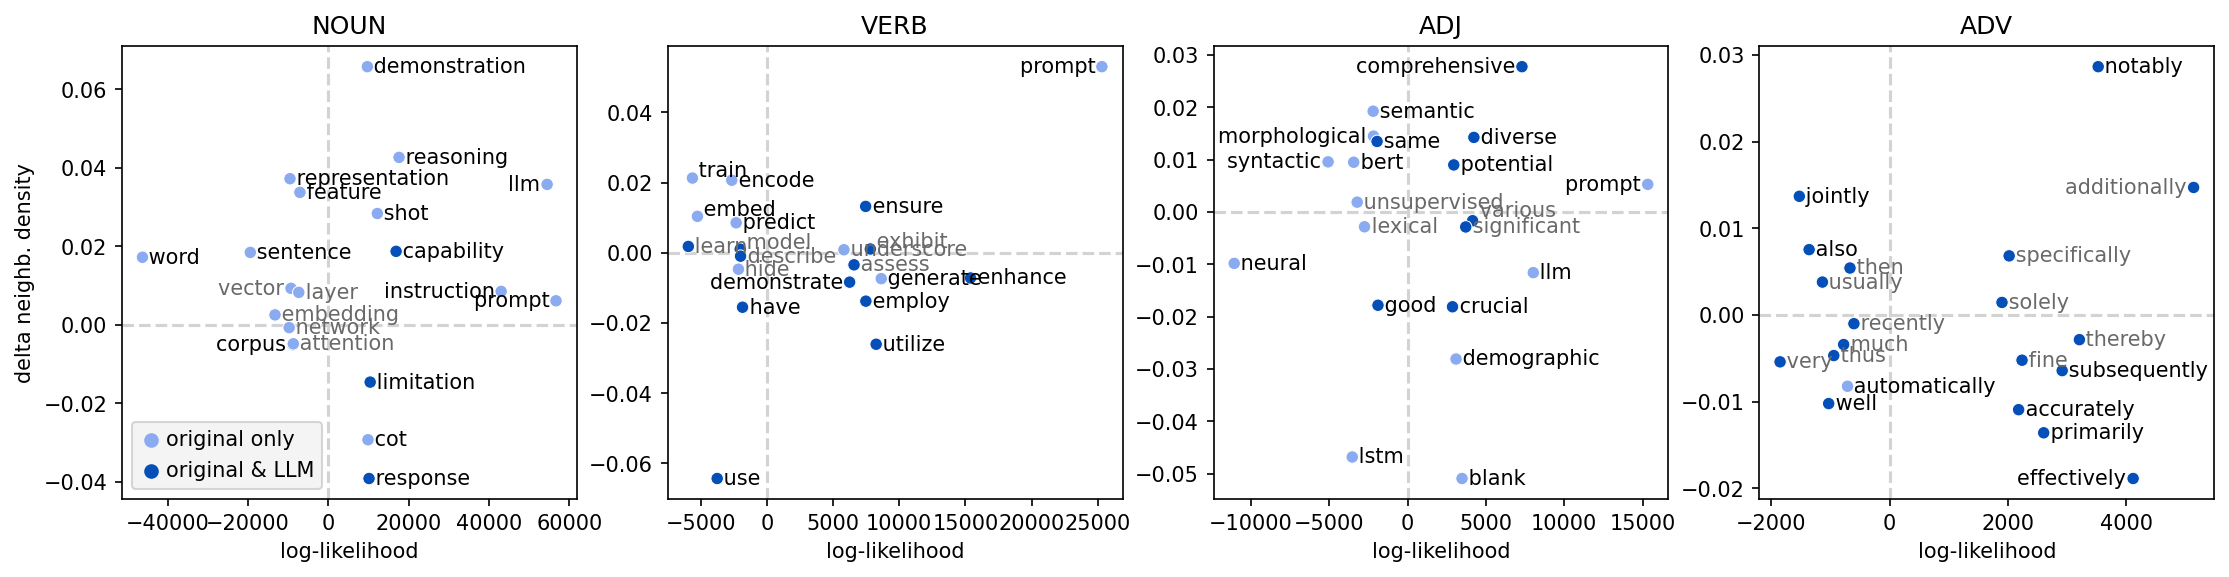

In [12]:
# Plot setup
pos_tags = ['NOUN', 'VERB', 'ADJ', 'ADV']
palette = {'original only': '#8babf1',
           'original & LLM': '#054fb9'}

# Manual fine-tuning of label positions
toleft = {'NOUN': ['llm', 'instruction', 'prompt', 'vector', 'corpus'],
          'VERB': ['demonstrate', 'prompt'],
          'ADJ': ['comprehensive', 'prompt', 'morphological', 'syntactic'],
          'ADV': ['additionally', 'effectively']}
tohigh = {'NOUN': [],
          'VERB': ['train', 'embed', 'model', 'exhibit'],
          'ADJ': ['various'],
          'ADV': []}

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(18, 4), dpi=150)

for i, pos in enumerate(pos_tags):

    plotdf = topdf[topdf['pos']==pos]
    sns.scatterplot(data=plotdf,
                    x='signed_ll',
                    y='delta_nn',
                    hue='Corpus',
                    palette=palette,
                    ax=ax[i])
    
    for row in plotdf.itertuples():
        kwargs = {'va': 'center'}
        if row.pval > 0.05:
            kwargs['color'] = 'dimgray'
        
        # Move label left of marker (if applicable)
        if row.lemma in toleft[pos]:
            kwargs['ha'] = 'right'
            lemma = row.lemma + ' '
        else:
            lemma = ' ' + row.lemma

        # Move label higher up (if applicable)
        if row.lemma in tohigh[pos]:
            y = row.delta_nn + 0.002
        else:
            y = row.delta_nn
            
        ax[i].text(x=row.signed_ll, y=y, s=lemma, **kwargs)
    
    # Add coordinate lines
    ax[i].axhline(y=0, ls='dashed', c='lightgrey', zorder=-1)
    ax[i].axvline(x=0, ls='dashed', c='lightgrey', zorder=-1)
    
    # Set up labels
    ax[i].set_title(pos)
    ax[i].set_axisbelow(True)
    ax[i].set_xlabel('log-likelihood')
    if i == 0:
        ax[i].set_ylabel('delta neighb. density')
    else:
        ax[i].set_ylabel(None)

    # Set up legend
    if i == 0:
        ax[i].legend(loc='lower left',
                     handletextpad=0.2,
                     handlelength=1,
                     facecolor='0.95')
    else:
        ax[i].get_legend().remove()

### Strongest changes in frequency -- table (appendix)

In [13]:
def get_overlap(target, direction, gpt_df):
    # Checks whether a target is significant in LLM corpus
    # for a direction which is one of ['t1', 't2']
    
    if direction == 't1':
        out = gpt_df[(gpt_df['target'] == target) & (gpt_df['ratio_t1'] > 1)].shape[0]
    elif direction == 't2':
        out = gpt_df[(gpt_df['target'] == target) & (gpt_df['ratio_t1'] < 1)].shape[0] 
    else:
        raise ValueError()

    if out == 0:
        out = ' '
    elif out == 1:
        out = '*'
    else:
        out = 'err'
    
    return out

In [14]:
# Add overlap information into dataframe
topdf['direction'] = topdf.apply(lambda x: 't1' if x.ratio_t1 > 1 else 't2', axis=1)
topdf['overlap'] = topdf.apply(lambda x: get_overlap(x.target, x.direction, topdf_gpt), axis=1)

In [15]:
# Prepare output -- naturalistic corpus + overlap with top 100 in LLM corpus
out_cols = ['overlap', 'lemma', 'freq_norm1', 'freq_norm2', 'll',
           'mean1', 'mean2', 'delta_nn', 'stat', 'pval']
out = topdf[out_cols].copy()

In [16]:
def get_significance(pval):
    if pval < 0.001:
        out = '***'
    elif pval < 0.01:
        out = '**'
    elif pval < 0.05:
        out = '*'
    else:
        out = 'ns'
    return out

In [17]:
rounding = {'freq_norm1': 1, 'freq_norm2': 1, 'll': 1,
            'stat': 1, 'mean1': 3, 'mean2': 3, 'delta_nn': 3} 
for col in rounding:
    dec_places = rounding[col]
    if dec_places == 0:
        formatter = lambda x: '{:.0f}'.format(x)
    elif dec_places == 1:
        formatter = lambda x: '{:.1f}'.format(x)
    elif dec_places == 3:
        formatter = lambda x: '{:.3f}'.format(x)
    out[col] = out[col].apply(formatter)

out['pval'] = out['pval'].apply(get_significance)

In [18]:
# Redo top LLM changes -- but only top 10
# (not for overlap with naturalistic corpus but for direct top10 comparison)
topn = 10 # per direction
pos_tags = ['NOUN', 'ADJ', 'VERB', 'ADV']
min_chars = 3

subdfs = []
for pos in pos_tags:
    subdf = df_gpt.loc[(df_gpt['pos'] == pos) &
                       (df_gpt['lemma'].str.isalpha()) &
                       (df_gpt['lemma'].str.len() >= min_chars)]\
                  .sort_values(by='ll', ascending=False)
    subdfs.append(subdf[subdf['ratio_t2']>1][:topn])
    subdfs.append(subdf[subdf['ratio_t2']<1][:topn])
topdf_gpt = pd.concat(subdfs, ignore_index=True)

topdf_gpt['signed_ll'] = topdf_gpt.apply(lambda x: -(x.ll) if x.ratio_t2 < 1 else x.ll, axis=1)

In [19]:
# Prepare LLM output
out_cols_gpt = ['lemma', 'freq_norm1', 'freq_norm2', 'll']
out_gpt = topdf_gpt[out_cols_gpt].copy()
for col in out_gpt.columns[1:]:
    out_gpt[col] = out_gpt[col].apply(lambda x: '{:.1f}'.format(x))

In [20]:
# Concatenate naturalistic + LLM lists
final_out = pd.concat([out, out_gpt], axis=1)
final_out.head()

,overlap,lemma,freq_norm1,freq_norm2,ll,mean1,mean2,delta_nn,stat,pval,lemma,freq_norm1,freq_norm2,ll
0,,prompt,169.2,910.0,56679.7,0.620,0.626,0.006,4122.0,*,study,879.5,2249.8,303.0
1,,llm,1.9,403.9,54465.4,0.618,0.653,0.036,1834.0,***,approach,1389.7,2565.0,173.0
2,,instruction,94.9,613.6,43024.1,0.567,0.575,0.008,4038.0,*,challenge,397.9,1079.6,159.5
3,,reasoning,223.9,593.3,17605.8,0.632,0.675,0.043,2455.5,***,research,757.1,1514.3,125.6
4,*,capability,83.3,339.2,16869.6,0.629,0.647,0.019,3248.0,***,advancement,12.2,216.3,108.1


In [21]:
# Print LaTeX version (if set to True)
print_latex = False
if print_latex:
    latex = final_out.to_latex(index=False).split('\n')
    for i, line in enumerate(latex[4:84]):
        if i % 20 == 0:
            print('%')
        elif i % 10 == 0:
            print('\midrule')
        print(line)